<a href="https://colab.research.google.com/github/KaykySchunck/Analyzer-de-Roupas---Visao-computacional---Deit-Vit/blob/main/CP_ArnaldoComputVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 13 — Vision Transformers: ViT e DeiT-Tiny (Fashion-MNIST)

## Objetivos
1. Explorar ViT pré-treinado com `timm` (inferência zero-shot no ImageNet)
2. Fine-tuning do DeiT-Tiny no Fashion-MNIST com timm + transformers
3. Comparar com CNN do zero (Lab 10) e Transfer Learning CNN (Lab 12)
4. Salvar artefato para deploy via FastAPI

---
**GPU recomendada** — DeiT-Tiny é leve (~5.7M params) e roda em CPU, mas GPU acelera o treino ~5×.


In [11]:
%pip install transformers timm accelerate datasets torch torchvision pillow matplotlib

In [12]:
import timm
import torch
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {device}')

# Listar modelos ViT disponíveis no timm
vit_models = timm.list_models('deit_*', pretrained=True)

print(f'Modelos ViT disponíveis: {len(vit_models)}')
print('Exemplos:', vit_models[:5])

Usando: cuda
Modelos ViT disponíveis: 8
Exemplos: ['deit_base_distilled_patch16_224.fb_in1k', 'deit_base_distilled_patch16_384.fb_in1k', 'deit_base_patch16_224.fb_in1k', 'deit_base_patch16_384.fb_in1k', 'deit_small_distilled_patch16_224.fb_in1k']


In [13]:
!nvidia-smi

Tue Aug 25 01:51:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
# Carregar DeiT-Tiny pré-treinado via timm
modelo_pre_treinado_timm = timm.create_model('deit_tiny_patch16_224', pretrained=True)
modelo_pre_treinado_timm.eval().to(device)

print(f'Parâmetros: {sum(p.numel() for p in modelo_pre_treinado_timm.parameters()):,}')

# Pré-processamento padrão do timm
data_config = timm.data.resolve_model_data_config(modelo_pre_treinado_timm)
transforms = timm.data.create_transform(**data_config, is_training=False)
print('\nTransforms:', transforms)

model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Parâmetros: 5,717,416

Transforms: Compose(
    Resize(size=248, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


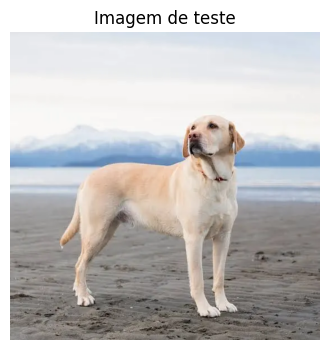

Top-5 previsões (DeiT-Tiny, ImageNet):
  Labrador retriever              60.2%
  Saluki                          12.6%
  Great Dane                      4.0%
  golden retriever                2.0%
  English foxhound                1.0%


In [15]:
import urllib.request

# 1. Baixar uma imagem de teste automaticamente para garantir que o código funcione
url_imagem = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQs1OtM7dKWRBrkYKSSnldgGFOYJicEf-PpieXLBgTepd2TYEGWFViCaGKBv4Ei1BbvNiq7Fcr61tCbd26Exzgl0O0rsq2J6wE9KMSuNBU&s=10'
urllib.request.urlretrieve(url_imagem, 'imagem_teste.jpg')

# 2. Carregar a imagem
img = Image.open('imagem_teste.jpg').convert('RGB')

# 3. Pré-processamento
tensor = transforms(img).unsqueeze(0).to(device)

# 4. Inferência
with torch.no_grad():
    logits = modelo_pre_treinado_timm(tensor)
    probs = torch.softmax(logits, dim=1)[0]

# 5. Top-5
top5_probs, top5_idx = torch.topk(probs, 5)

# 6. Rótulos do ImageNet
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt',
    'imagenet_classes.txt'
)
with open('imagenet_classes.txt') as f:
    imagenet_classes = [l.strip() for l in f]

# 7. Visualização
plt.figure(figsize=(4, 4))
plt.imshow(img); plt.axis('off'); plt.title('Imagem de teste')
plt.show()

print('Top-5 previsões (DeiT-Tiny, ImageNet):')
for i, p in zip(top5_idx, top5_probs):
    print(f'  {imagenet_classes[i]:30s}  {p*100:.1f}%')

## Parte 2 — Fine-tuning do DeiT-Tiny no Fashion-MNIST (timm + transformers)

In [1]:
import json
from pathlib import Path
import torchvision
import torchvision.transforms as T
from transformers import AutoImageProcessor

CLASSES = ['camiseta', 'calca', 'sueter', 'vestido', 'casaco',
           'sandalia', 'camisa', 'tenis', 'bolsa', 'bota']
MODEL_ID_TIMM = 'deit_tiny_patch16_224'
MODEL_ID_HF = 'facebook/deit-tiny-patch16-224'

In [16]:
# Cria o modelo já trocando a cabeça para 10 classes — o timm faz isso sozinho
modelo_deit = timm.create_model(MODEL_ID_TIMM, pretrained=True, num_classes=10)
modelo_deit = modelo_deit.to(device)

# Reaproveita o mesmo padrão de pré-processamento da Parte 1
data_config_ft = timm.data.resolve_model_data_config(modelo_deit)
size = data_config_ft['input_size'][-1]

tf_train = T.Compose([
    T.Grayscale(num_output_channels=3),  # Fashion-MNIST é 1 canal, DeiT espera 3
    T.Resize((size, size)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=data_config_ft['mean'], std=data_config_ft['std']),
])
tf_val = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((size, size)),
    T.ToTensor(),
    T.Normalize(mean=data_config_ft['mean'], std=data_config_ft['std']),
])

trainset = torchvision.datasets.FashionMNIST('./data', train=True,  download=True, transform=tf_train)
testset  = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=tf_val)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True,  num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64, shuffle=False, num_workers=2)

print(f'Treino: {len(trainset)} | Teste: {len(testset)}')

treinaveis = sum(p.numel() for p in modelo_deit.parameters() if p.requires_grad)
total = sum(p.numel() for p in modelo_deit.parameters())
print(f'Parâmetros treináveis: {treinaveis:,} / {total:,}')

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.2MB/s]

Treino: 60000 | Teste: 10000
Parâmetros treináveis: 5,526,346 / 5,526,346


In [18]:
import torch.nn as nn
from tqdm.notebook import tqdm

optimizer = torch.optim.AdamW(modelo_deit.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
NUM_EPOCHS = 5  # Fashion-MNIST é simples, poucas épocas já rendem boa acurácia
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

historico = {'train_acc': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    modelo_deit.train()
    corretos = total_b = 0

    # Barra de progresso do treino dessa época
    barra_treino = tqdm(trainloader, desc=f'Época {epoch+1}/{NUM_EPOCHS} [treino]')
    for imgs, labels in barra_treino:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = modelo_deit(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        corretos += (outputs.argmax(1) == labels).sum().item()
        total_b += labels.size(0)

        # Atualiza a barra mostrando loss e acurácia parcial em tempo real
        barra_treino.set_postfix(loss=f'{loss.item():.3f}', acc=f'{100*corretos/total_b:.1f}%')

    train_acc = 100 * corretos / total_b

    modelo_deit.eval()
    c_val = t_val = 0

    # Barra de progresso da validação
    barra_val = tqdm(testloader, desc=f'Época {epoch+1}/{NUM_EPOCHS} [validação]')
    with torch.no_grad():
        for imgs, labels in barra_val:
            imgs, labels = imgs.to(device), labels.to(device)
            out = modelo_deit(imgs)
            c_val += (out.argmax(1) == labels).sum().item()
            t_val += labels.size(0)
            barra_val.set_postfix(acc=f'{100*c_val/t_val:.1f}%')

    val_acc = 100 * c_val / t_val
    scheduler.step()

    historico['train_acc'].append(train_acc)
    historico['val_acc'].append(val_acc)
    print(f'Época {epoch+1:02d}/{NUM_EPOCHS} | Treino: {train_acc:.1f}% | Val: {val_acc:.1f}%')

Época 1/5 [treino]:   0%|          | 0/938 [00:00<?, ?it/s]

Época 1/5 [validação]:   0%|          | 0/157 [00:00<?, ?it/s]

Época 01/5 | Treino: 88.4% | Val: 92.2%


Época 2/5 [treino]:   0%|          | 0/938 [00:00<?, ?it/s]

Época 2/5 [validação]:   0%|          | 0/157 [00:00<?, ?it/s]

...

Época 4/5 [validação]:   0%|          | 0/157 [00:00<?, ?it/s]

Época 04/5 | Treino: 95.9% | Val: 93.7%


Época 5/5 [treino]:   0%|          | 0/938 [00:00<?, ?it/s]

Época 5/5 [validação]:   0%|          | 0/157 [00:00<?, ?it/s]

Época 05/5 | Treino: 96.8% | Val: 94.1%


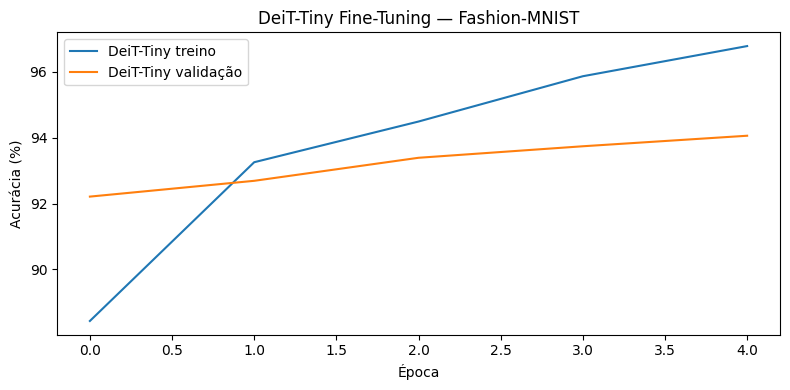

Melhor val acc: 94.1%


In [22]:
plt.figure(figsize=(8, 4))
plt.plot(historico['train_acc'], label='DeiT-Tiny treino')
plt.plot(historico['val_acc'],   label='DeiT-Tiny validação')
plt.title('DeiT-Tiny Fine-Tuning — Fashion-MNIST')
plt.xlabel('Época'); plt.ylabel('Acurácia (%)')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Melhor val acc: {max(historico["val_acc"]):.1f}%')

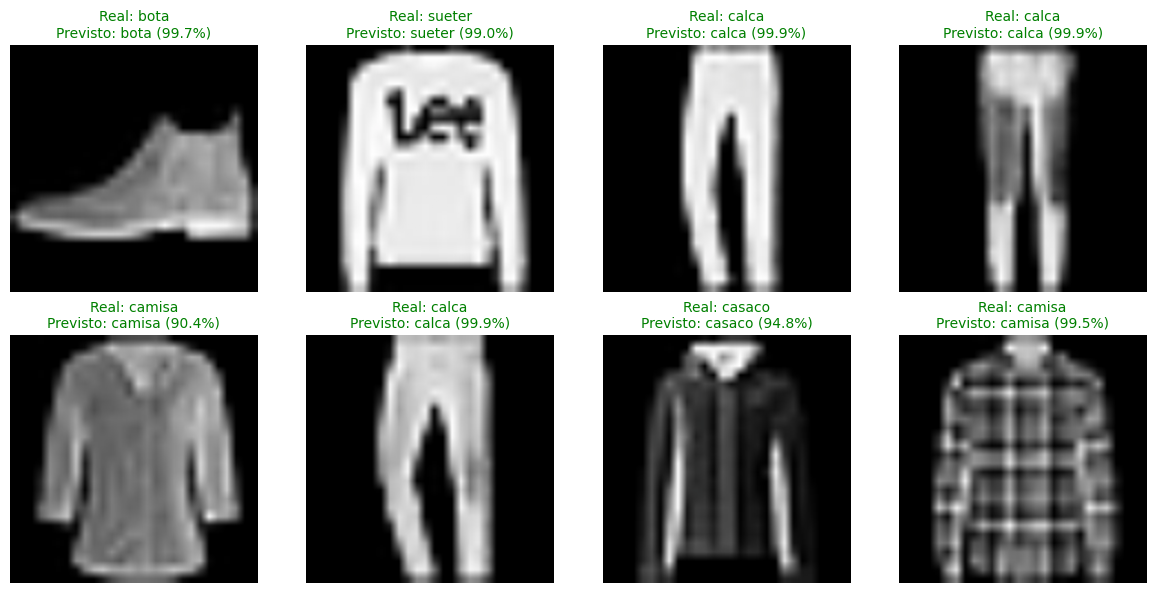

In [24]:
# Visualizar algumas roupas de teste com a previsão do modelo já treinado
modelo_deit.eval()

# Pega um batch do testloader (as imagens já vêm normalizadas/transformadas)
imgs, labels = next(iter(testloader))
imgs, labels = imgs.to(device), labels.to(device)

with torch.no_grad():
    outputs = modelo_deit(imgs)
    probs = torch.softmax(outputs, dim=1)       # transforma os logits em probabilidades (0 a 1)
    confs, preds = probs.max(dim=1)              # pega a maior probabilidade e seu índice, por imagem

# Para mostrar a imagem "normal" (sem a normalização matemática), precisamos desfazer
# a normalização feita no tf_val, senão a imagem aparece com cores estranhas
mean = torch.tensor(data_config_ft['mean']).view(3, 1, 1)
std = torch.tensor(data_config_ft['std']).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, label, pred, conf in zip(axes.flatten(), imgs.cpu(), labels.cpu(), preds.cpu(), confs.cpu()):
    img_desnormalizada = img * std + mean          # desfaz a normalização
    img_desnormalizada = img_desnormalizada.clamp(0, 1)  # garante valores entre 0 e 1
    img_np = img_desnormalizada.permute(1, 2, 0).numpy()  # reorganiza para o formato que o matplotlib espera

    ax.imshow(img_np)
    cor = 'green' if pred == label else 'red'
    ax.set_title(f'Real: {CLASSES[label]}\nPrevisto: {CLASSES[pred]} ({conf*100:.1f}%)', color=cor, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Parte 3 — Salvar artefato

In [ ]:
artifacts_dir = Path('artifacts/deit_fashion_mnist')
artifacts_dir.mkdir(parents=True, exist_ok=True)

# O timm não tem save_pretrained padronizado, então salvamos os pesos manualmente
torch.save(modelo_deit.state_dict(), artifacts_dir / 'pytorch_model.bin')

# Usamos o transformers só para gerar a config de pré-processamento padronizada
processor = AutoImageProcessor.from_pretrained(MODEL_ID_HF)
processor.save_pretrained(str(artifacts_dir))

metadata = {
    'model_name': 'DeiT-Tiny (fine-tuned Fashion-MNIST, via timm)',
    'base_model_timm': MODEL_ID_TIMM,
    'base_model_hf_equivalent': MODEL_ID_HF,
    'dataset': 'Fashion-MNIST',
    'num_classes': 10,
    'classes': CLASSES,
    'val_acc': round(max(historico['val_acc']), 2),
}
Path('artifacts/metadata.json').write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8'
)

print('Artefatos salvos:')
for f in sorted(Path('artifacts').rglob('*')):
    if f.is_file():
        print(f'  {f}  ({f.stat().st_size/1024:.0f} KB)')